<a href="https://www.kaggle.com/code/lalit7881/smartphone-specifications-pricing-eda?scriptVersionId=313490555" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aryanmdev/smartphone-specifications-and-pricing-eda-ready/device_specs_structured_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aryanmdev/smartphone-specifications-and-pricing-eda-ready/device_specs_structured_dataset.csv")

In [3]:
df.head()

,phone_name,url,brand,price_raw,price_inr,launch_date,operating_system,chipset,ram_raw,storage_raw,...,fast_charging_raw,display_raw,display_type,resolution,sim_type,network_support,bluetooth_raw,nfc_raw,source,list_price_inr
0,Samsung Galaxy Z Fold7,https://www.91mobiles.com/samsung-galaxy-z-fol...,samsung,"₹174,999(In Stock)",174999,"July 25, 2025 (Official)",Android v16,Qualcomm Snapdragon 8 Elite SM8750,12 GB / 16 GB,256 GB / 512 GB / 1 TB,...,"Yes, 25W Fast Charging, 50% in 30 minutes","8.0"", 1968 x 2184 Resolution",Dynamic AMOLED 2x,1968x2184 px,"SIM1: Nano, SIM2: Nano","5G, 4G","Yes, v5.4",Yes,product+list,174999.0
1,Samsung Galaxy Z Flip7,https://www.91mobiles.com/samsung-galaxy-z-fli...,samsung,"₹109,999(In Stock)",109999,"July 25, 2025 (Official)",Android v16,Samsung Exynos 2500,12 GB,256 GB / 512 GB,...,"Yes, 25W Fast Charging, 50% in 30 minutes","6.9"", 1080 x 2520 Resolution",Dynamic AMOLED 2x,1080x2520 px (FHD),"SIM1: Nano, SIM2: eSIM","5G, 4G","Yes, v5.4",Yes,product+list,121999.0
2,Samsung Galaxy S25 Ultra,https://www.91mobiles.com/samsung-galaxy-s25-u...,samsung,"₹118,999(In Stock)",118999,"January 22, 2025 (Official)",Android v15,Qualcomm Snapdragon 8 Elite,12 GB,256 GB / 512 GB / 1 TB,...,"Yes, 45W Fast Charging, 65% in 30 minutes","6.9"", 1440 x 3120 Resolution",Dynamic AMOLED 2x,1440x3120 px (QHD+),"SIM1: Nano, SIM2: eSIM","5G, 4G","Yes, v5.4",Yes,product+list,141999.0
3,Samsung Galaxy S26 Ultra,https://www.91mobiles.com/samsung-galaxy-s26-u...,samsung,"₹126,790(In Stock)",126790,"February 25, 2026 (Official)",Android v16,Qualcomm Snapdragon 8 Elite Gen 5 SM8850-AC,12 GB / 16 GB,256 GB / 512 GB / 1 TB,...,"Yes, 60W Super Fast Charging v3.0, 75% in 30 m...","6.9"", 1440 x 3120 Resolution",Dynamic AMOLED 2x,1440x3120 px (QHD+),"SIM1: Nano, SIM2: eSIM","5G, 4G","Yes, v6.0",Yes,product+list,126790.0
4,Samsung Galaxy A57 5G,https://www.91mobiles.com/samsung-galaxy-a57-p...,samsung,"₹56,999(In Stock)",56999,"March 25, 2026 (Official)",Android v16,Samsung Exynos 1680,8 GB / 12 GB,256 GB,...,"Yes, 45W Fast Charging, 60% in 30 minutes","6.7"", 1080 x 2340 Resolution",Super AMOLED Plus,1080x2340 px (FHD+),"SIM1: Nano, SIM2: Nano/eSIM","5G, 4G","Yes, v6.0",Yes,product+list,56999.0


In [4]:
df.tail()

,phone_name,url,brand,price_raw,price_inr,launch_date,operating_system,chipset,ram_raw,storage_raw,...,fast_charging_raw,display_raw,display_type,resolution,sim_type,network_support,bluetooth_raw,nfc_raw,source,list_price_inr
295,Nokia 6310,https://www.91mobiles.com/nokia-6310-price-in-...,nokia,"₹3,699(In Stock)",3699,"September 16, 2021 (Official)",NaN,NaN,16 MB,8 MB,...,NaN,"2.8"", 240 x 320 Resolution",TFT,240x320 px,NaN,5G Not Supported,"Yes, v5.0",NaN,product+list,3699.0
296,Nokia 215 2020,https://www.91mobiles.com/nokia-215-2020-price...,nokia,"₹3,793(In Stock)",3793,"November 11, 2020 (Official)",NaN,Unisoc UMS9117,64 MB,128 MB,...,NaN,"2.4"", 240 x 320 Resolution",TFT,240x320 px,"SIM1: Nano, SIM2: Nano","5G Not Supported, 4G","Yes, v5.0",NaN,product+list,3793.0
297,Nokia 225 2020,https://www.91mobiles.com/nokia-225-2020-price...,nokia,"₹4,399(In Stock)",4399,"October 21, 2020 (Official)",NaN,Unisoc UMS9117,64 MB,128 MB,...,NaN,"2.4"", 240 x 320 Resolution",TFT,240x320 px,"SIM1: Nano, SIM2: Nano","5G Not Supported, 4G","Yes, v5.0",NaN,product+list,4399.0
298,Nokia 105 Classic Dual SIM,https://www.91mobiles.com/nokia-105-classic-du...,nokia,"₹1,209(In Stock)",1209,"November 6, 2023 (Official)",NaN,NaN,4 MB,4 MB,...,NaN,"1.77"", 128 x 160 Resolution",TFT,128x160 px,"SIM1: Mini, SIM2: Mini",5G Not Supported,NaN,NaN,product+list,1209.0
299,Nokia G10,https://www.91mobiles.com/nokia-g10-price-in-i...,nokia,"₹12,999(In Stock)",12999,"September 13, 2021 (Official)",Android v11,MediaTek Helio G25,4 GB,64 GB,...,NaN,"6.5"", 720 x 1600 Resolution",IPS LCD,720x1600 px (HD+),"SIM1: Nano, SIM2: Nano","5G Not Supported, 4G","Yes, v5.0",No,product+list,12999.0


In [5]:
df.columns

Index(['phone_name', 'url', 'brand', 'price_raw', 'price_inr', 'launch_date',
       'operating_system', 'chipset', 'ram_raw', 'storage_raw',
       'rear_camera_raw', 'front_camera_raw', 'battery_raw',
       'fast_charging_raw', 'display_raw', 'display_type', 'resolution',
       'sim_type', 'network_support', 'bluetooth_raw', 'nfc_raw', 'source',
       'list_price_inr'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   phone_name         300 non-null    object 
 1   url                300 non-null    object 
 2   brand              300 non-null    object 
 3   price_raw          300 non-null    object 
 4   price_inr          300 non-null    int64  
 5   launch_date        282 non-null    object 
 6   operating_system   287 non-null    object 
 7   chipset            291 non-null    object 
 8   ram_raw            296 non-null    object 
 9   storage_raw        295 non-null    object 
 10  rear_camera_raw    293 non-null    object 
 11  front_camera_raw   282 non-null    object 
 12  battery_raw        300 non-null    object 
 13  fast_charging_raw  274 non-null    object 
 14  display_raw        300 non-null    object 
 15  display_type       298 non-null    object 
 16  resolution         299 non

In [7]:
df.describe()

,price_inr,list_price_inr
count,300.000000,284.000000
mean,40797.636667,37338.816901
std,38490.503229,34792.993612
min,1132.000000,1132.000000
25%,16936.500000,15999.000000
50%,26999.000000,26149.000000
75%,47124.250000,42139.000000
max,222990.000000,222990.000000


In [8]:
df.isnull().sum()

phone_name            0
url                   0
brand                 0
price_raw             0
price_inr             0
launch_date          18
operating_system     13
chipset               9
ram_raw               4
storage_raw           5
rear_camera_raw       7
front_camera_raw     18
battery_raw           0
fast_charging_raw    26
display_raw           0
display_type          2
resolution            1
sim_type              4
network_support       1
bluetooth_raw         5
nfc_raw              54
source                0
list_price_inr       16
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

phone_name            object
url                   object
brand                 object
price_raw             object
price_inr              int64
launch_date           object
operating_system      object
chipset               object
ram_raw               object
storage_raw           object
rear_camera_raw       object
front_camera_raw      object
battery_raw           object
fast_charging_raw     object
display_raw           object
display_type          object
resolution            object
sim_type              object
network_support       object
bluetooth_raw         object
nfc_raw               object
source                object
list_price_inr       float64
dtype: object

In [11]:
df.shape

(300, 23)

In [12]:
df.nunique()

phone_name           300
url                  300
brand                 15
price_raw            185
price_inr            175
launch_date          193
operating_system      16
chipset              134
ram_raw               25
storage_raw           17
rear_camera_raw       75
front_camera_raw      17
battery_raw           80
fast_charging_raw    139
display_raw          103
display_type          31
resolution            65
sim_type               8
network_support        3
bluetooth_raw          9
nfc_raw                2
source                 1
list_price_inr       175
dtype: int64

## EDA

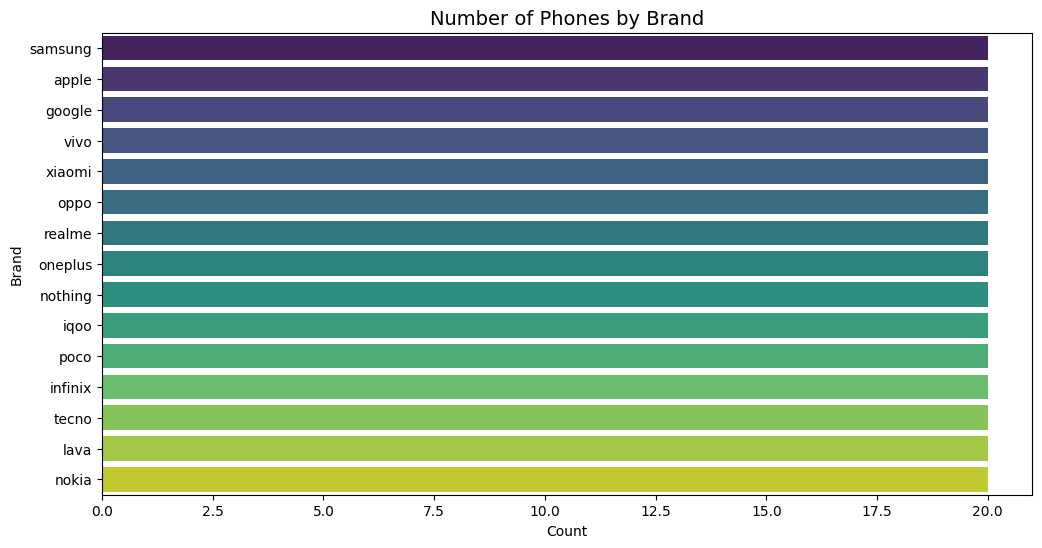

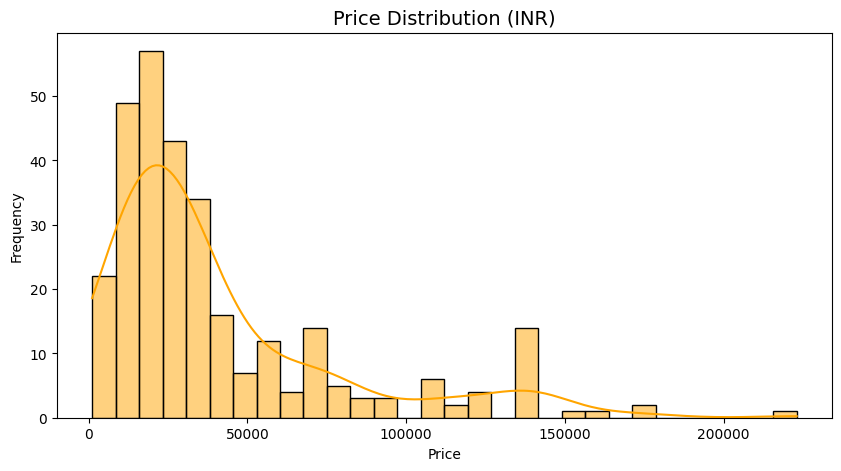

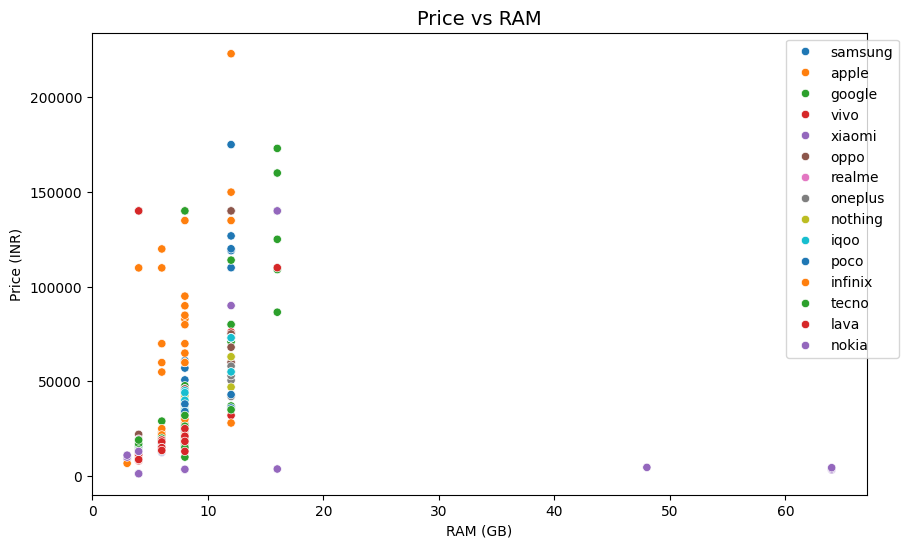

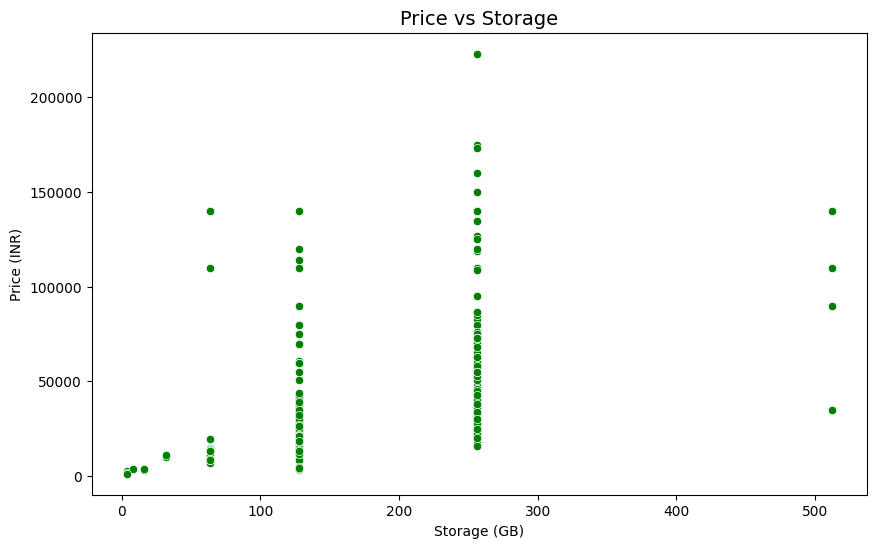

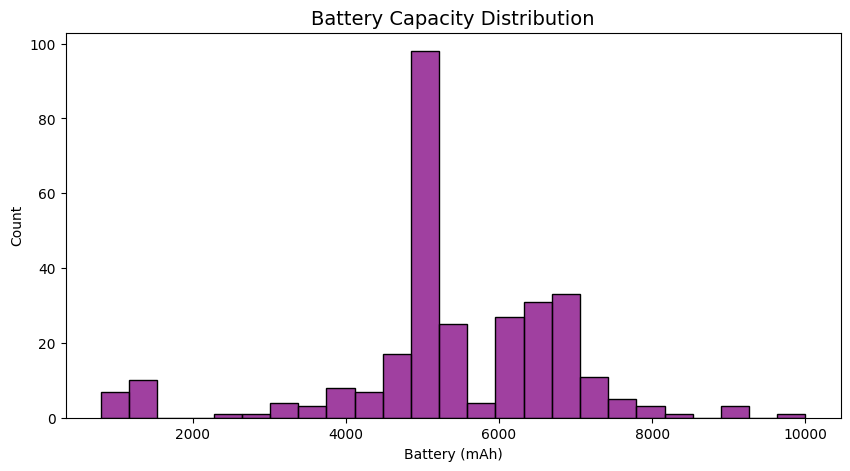

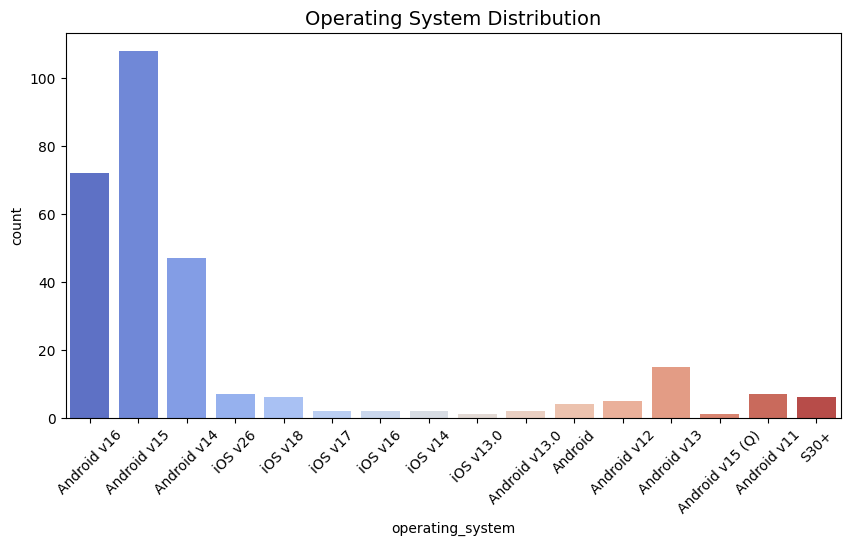

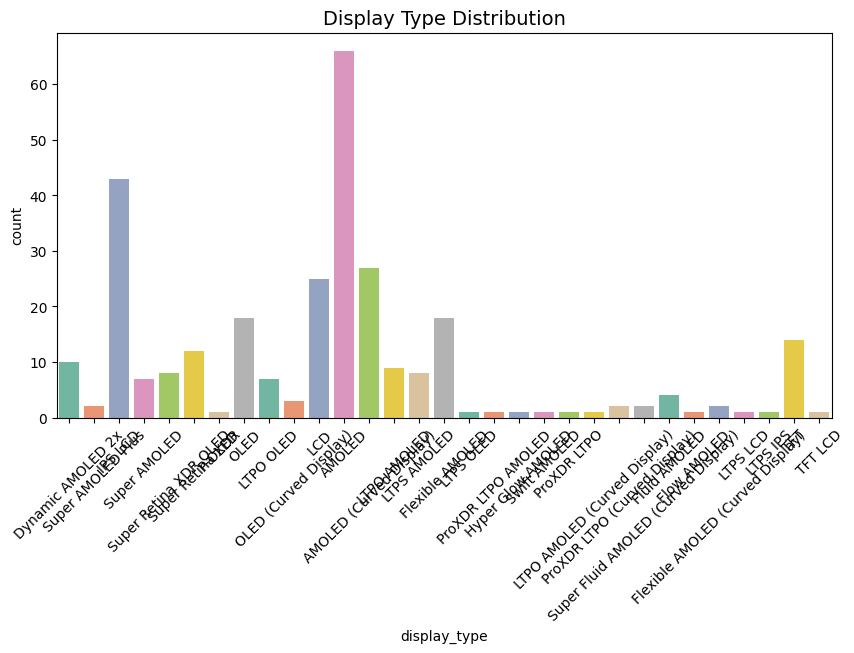

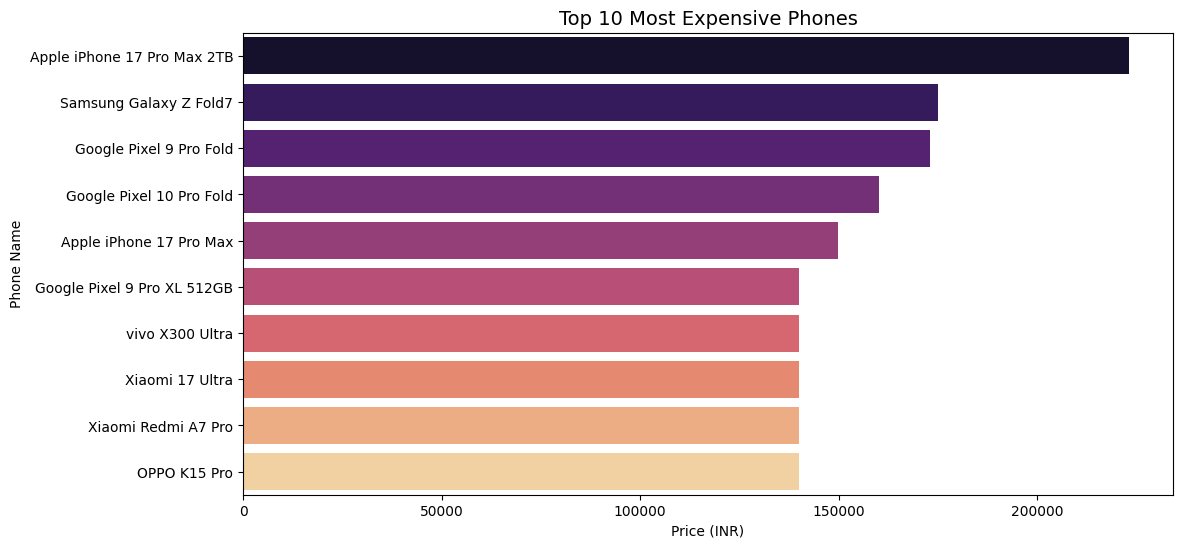

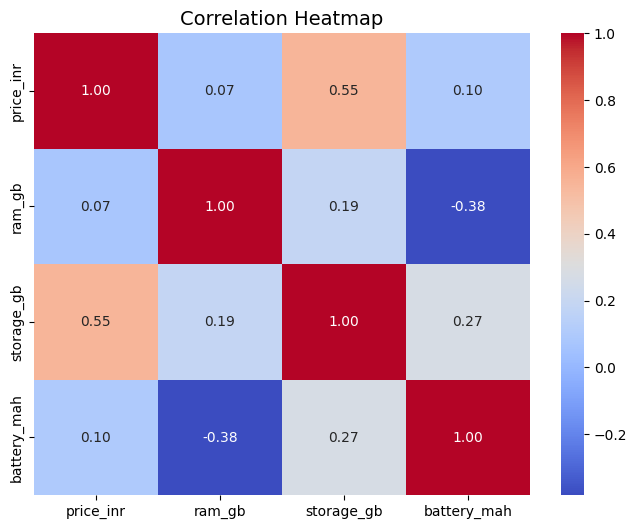

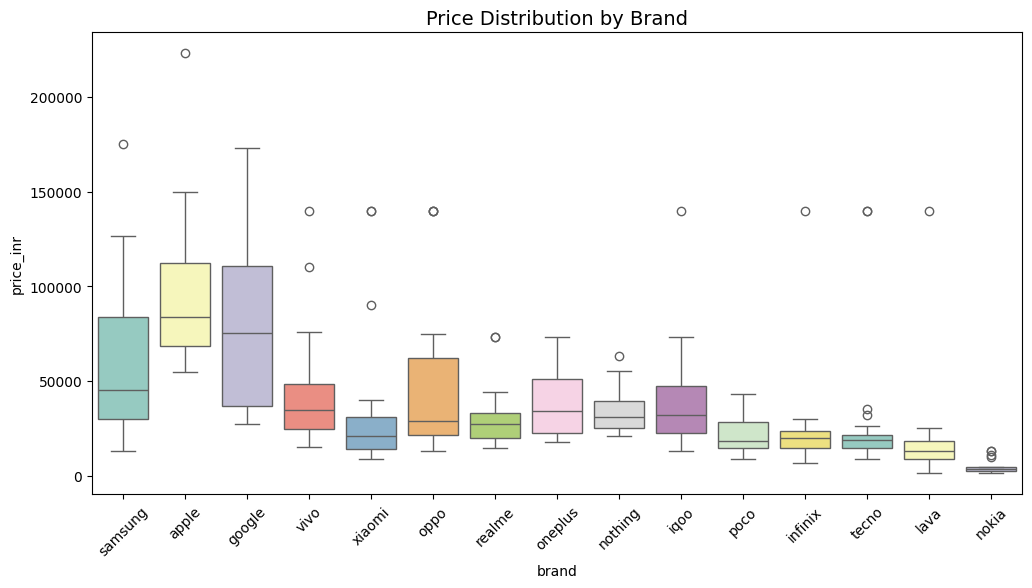

In [13]:
# Convert price to numeric
df['price_inr'] = pd.to_numeric(df['price_inr'], errors='coerce')

# Extract RAM (numbers only)
df['ram_gb'] = df['ram_raw'].str.extract('(\d+)').astype(float)

# Extract Storage
df['storage_gb'] = df['storage_raw'].str.extract('(\d+)').astype(float)

# Extract Battery
df['battery_mah'] = df['battery_raw'].str.extract('(\d+)').astype(float)

# Drop null values for plotting
df_clean = df.dropna(subset=['price_inr'])

# =========================
# 1. BRAND COUNT PLOT
# =========================
plt.figure(figsize=(12,6))
sns.countplot(data=df_clean, y='brand', order=df_clean['brand'].value_counts().index,
              palette='viridis')
plt.title("Number of Phones by Brand", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Brand")
plt.show()

# =========================
# 2. PRICE DISTRIBUTION
# =========================
plt.figure(figsize=(10,5))
sns.histplot(df_clean['price_inr'], bins=30, kde=True, color='orange')
plt.title("Price Distribution (INR)", fontsize=14)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# =========================
# 3. PRICE vs RAM
# =========================
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='ram_gb', y='price_inr',
                hue='brand', palette='tab10')
plt.title("Price vs RAM", fontsize=14)
plt.xlabel("RAM (GB)")
plt.ylabel("Price (INR)")
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()

# =========================
# 4. PRICE vs STORAGE
# =========================
plt.figure(figsize=(10,6))
sns.scatterplot(data=df_clean, x='storage_gb', y='price_inr',
                color='green')
plt.title("Price vs Storage", fontsize=14)
plt.xlabel("Storage (GB)")
plt.ylabel("Price (INR)")
plt.show()

# =========================
# 5. BATTERY DISTRIBUTION
# =========================
plt.figure(figsize=(10,5))
sns.histplot(df_clean['battery_mah'], bins=25, color='purple')
plt.title("Battery Capacity Distribution", fontsize=14)
plt.xlabel("Battery (mAh)")
plt.ylabel("Count")
plt.show()

# =========================
# 6. OPERATING SYSTEM COUNT
# =========================
plt.figure(figsize=(10,5))
sns.countplot(data=df_clean, x='operating_system',
              palette='coolwarm')
plt.title("Operating System Distribution", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# =========================
# 7. DISPLAY TYPE COUNT
# =========================
plt.figure(figsize=(10,5))
sns.countplot(data=df_clean, x='display_type',
              palette='Set2')
plt.title("Display Type Distribution", fontsize=14)
plt.xticks(rotation=45)
plt.show()

# =========================
# 8. TOP 10 EXPENSIVE PHONES
# =========================
top_expensive = df_clean.nlargest(10, 'price_inr')

plt.figure(figsize=(12,6))
sns.barplot(data=top_expensive, x='price_inr', y='phone_name',
            palette='magma')
plt.title("Top 10 Most Expensive Phones", fontsize=14)
plt.xlabel("Price (INR)")
plt.ylabel("Phone Name")
plt.show()

# =========================
# 9. CORRELATION HEATMAP
# =========================
numeric_cols = ['price_inr', 'ram_gb', 'storage_gb', 'battery_mah']

plt.figure(figsize=(8,6))
sns.heatmap(df_clean[numeric_cols].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap", fontsize=14)
plt.show()

# =========================
# 10. PRICE BY BRAND (BOXPLOT)
# =========================
plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean, x='brand', y='price_inr',
            palette='Set3')
plt.xticks(rotation=45)
plt.title("Price Distribution by Brand", fontsize=14)
plt.show()

## Feature engineering

Columns in dataset:
 ['phone_name', 'url', 'brand', 'price_raw', 'price_inr', 'launch_date', 'operating_system', 'chipset', 'ram_raw', 'storage_raw', 'rear_camera_raw', 'front_camera_raw', 'battery_raw', 'fast_charging_raw', 'display_raw', 'display_type', 'resolution', 'sim_type', 'network_support', 'bluetooth_raw', 'nfc_raw', 'source', 'list_price_inr', 'ram_gb', 'storage_gb', 'battery_mah']
Numeric Columns: ['ram_gb', 'storage_gb', 'battery_mah']
Categorical Columns: ['phone_name', 'brand', 'launch_date', 'operating_system', 'chipset', 'ram_raw', 'storage_raw', 'rear_camera_raw', 'front_camera_raw', 'battery_raw', 'fast_charging_raw', 'display_raw', 'display_type', 'resolution', 'sim_type', 'network_support', 'bluetooth_raw', 'nfc_raw']

Logistic Regression
Accuracy: 0.95
              precision    recall  f1-score   support

           0       0.94      0.97      0.95        30
           1       0.97      0.93      0.95        30

    accuracy                           0.95        

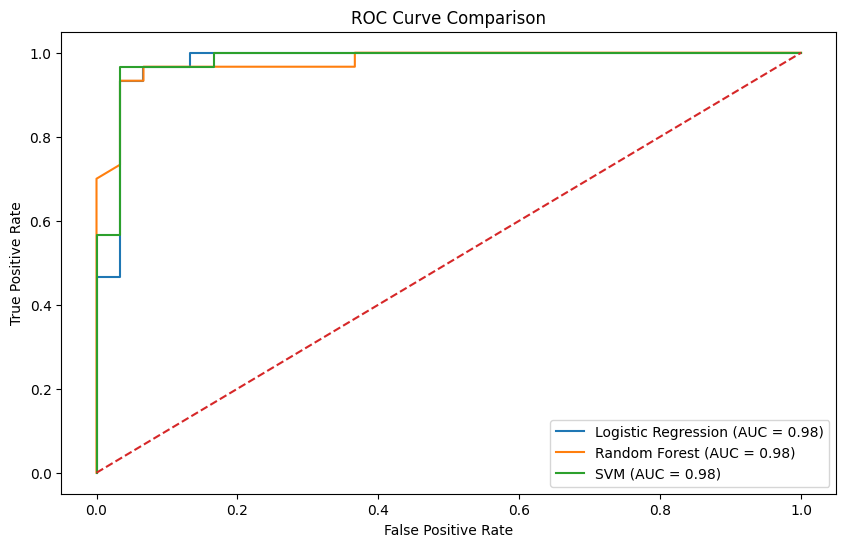


Final Accuracy Comparison:
Logistic Regression: 0.9500
Random Forest: 0.9500
SVM: 0.9167


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

print("Columns in dataset:\n", df.columns.tolist())

# =========================
# SAFE COLUMN DROP (NO ERROR)
# =========================
cols_to_drop = ['url', 'source', 'price_raw', 'list_price_inr']
df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

# =========================
# CLEAN NUMERIC DATA
# =========================
df['price_inr'] = pd.to_numeric(df['price_inr'], errors='coerce')

# Extract numeric values safely
def extract_number(col):
    return col.astype(str).str.extract('(\d+)').astype(float)

if 'ram_raw' in df.columns:
    df['ram_gb'] = extract_number(df['ram_raw'])

if 'storage_raw' in df.columns:
    df['storage_gb'] = extract_number(df['storage_raw'])

if 'battery_raw' in df.columns:
    df['battery_mah'] = extract_number(df['battery_raw'])

# =========================
# REMOVE ROWS WITHOUT PRICE
# =========================
df = df.dropna(subset=['price_inr'])

# =========================
# CREATE TARGET
# =========================
median_price = df['price_inr'].median()
df['target'] = (df['price_inr'] > median_price).astype(int)

# =========================
# FEATURES & TARGET
# =========================
X = df.drop(columns=['target', 'price_inr'])
y = df['target']

# =========================
# TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# AUTO DETECT COLUMN TYPES
# =========================
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric Columns:", numeric_features)
print("Categorical Columns:", categorical_features)

# =========================
# PIPELINES (NO NaN ERROR)
# =========================

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features)
])

# =========================
# MODELS
# =========================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True)
}

# =========================
# TRAIN + EVALUATE
# =========================
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # TRAIN
    pipeline.fit(X_train, y_train)
    
    # PREDICT
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    
    # ACCURACY
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print("\n====================")
    print(name)
    print("====================")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))
    
    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# =========================
# FINAL ROC PLOT
# =========================
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# =========================
# FINAL RESULTS
# =========================
print("\nFinal Accuracy Comparison:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")

## Thank you...pls upvote!!!!!!!!